# Faculty QIP Performance Dataset - Column Descriptions

## A. Personal & Professional Information (Basic Data)
1. **Faculty ID** – Unique identifier assigned to each faculty member.
2. **Department** – The department to which the faculty belongs (MCA, CSE, CSIT, AIDS).
3. **Experience (Years)** – Total teaching experience in years.
4. **Education Level** – Faculty's highest qualification (Ph.D. or Master’s).
5. **QIP Participation Count** – Number of Quality Improvement Programs attended by the faculty.
6. **Previous Performance Score** – Performance evaluation from previous assessments (0-100%).

## B. Teaching Performance (Quantitative & Qualitative)
7. **Student Feedback Score** – Average student rating of the faculty (Scale: 3.0 - 5.0).
8. **Pass Percentage of Students** – Percentage of students who passed the subject taught by the faculty (Scale: 60% - 100%).
9. **Innovative Teaching Methods Used** – Number of new teaching methodologies adopted.
10. **Class Attendance Rate (%)** – Average percentage of students attending the faculty's classes (Scale: 50% - 100%).

## C. Research & Publications
11. **Research Papers Published (Last 2 Years)** – Number of research papers published.
12. **Research Funding Secured (₹)** – Amount of research grants secured.
13. **Conference/Seminar Participation** – Number of conferences or seminars attended/presented.
14. **Patents Filed/Granted** – Number of patents filed or granted.

## D. Target Feature (To Be Calculated)
15. **Overall Faculty Performance Score** – The final weighted performance score (To be calculated based on various attributes).



This dataset is designed for **data cleaning, preprocessing, and predictive modeling** of faculty performance based on QIP participation.


## Preprocessing Steps
1. Load the Dataset
📂
2. Handle Missing Values (Impute or Drop) ❓

3. Detect and Handle Outliers (Using IQR/Z-Score) 🚨

4. Convert Categorical Data (Encoding) 🔄

5. Normalize/Scale Numerical Data 📏

6. Feature Engineering (If Needed) 🔬

## Step 1: Load the Dataset

In [1]:
import pandas as pd
import numpy as np

# Load dataset with all columns as strings to avoid type interpretation issues
file_path = r"E:\Odin\ML\QIP Project\QIP-dataset.csv"  
df = pd.read_csv(file_path)

In [17]:
df.head

,Faculty ID,Faculty Name,Department,Experience (Years),Qualification,QIP Participation Count,Previous Performance Score,Student Feedback Score,Pass Percentage of Students,Innovative Teaching Methods Used,Class Attendance Rate (%),Research Papers Published (Last 2 Years),Research Funding Secured (in Rs),Conference/Seminar Participation,Patents Filed/Granted,Overall Faculty Performance Score
0,FAC2000,A,CSE,28,Masters,5,99.21,3.31,63.0,5,68,5,NaN,6,2,NaN
1,FAC2001,B,MCA,20,Ph.D.,5,72.29,4.85,NaN,3,85,1,224740.0,9,2,NaN
2,FAC2002,C,CSIT,20,Ph.D.,5,94.20,4.51,85.0,3,70,1,325263.0,2,0,NaN
3,FAC2003,D,MCA,3,Ph.D.,9,70.48,4.55,86.0,1,84,9,NaN,1,2,NaN
4,FAC2004,E,CSE,31,Ph.D.,10,58.07,4.84,72.0,5,94,5,258654.0,6,2,NaN
5,FAC2005,F,CSE,30,Masters,8,59.24,3.18,NaN,0,85,1,322063.0,6,3,NaN
6,FAC2006,G,MCA,27,Masters,2,70.25,3.42,87.0,2,83,8,211250.0,4,1,NaN
7,FAC2007,H,AIDS,18,Ph.D.,8,56.08,NaN,96.0,3,113,2,941047.0,8,1,NaN
8,FAC2008,I,AIDS,2,Ph.D.,7,69.90,NaN,73.0,0,100,3,10894.0,3,0,NaN
9,FAC2009,J,AIDS,14,Masters,9,77.98,3.40,NaN,5,85,0,33208.0,8,3,NaN


In [128]:
# Assign titles based on qualifications
def assign_title(row):
    if row['Qualification'] == 'Ph.D.':
        return 'Dr. ' + row['Faculty Name'] 
    else:
        return 'Prof. ' + row['Faculty Name']

# Apply the function to modify the 'Faculty Name' column
df['Faculty Name'] = df.apply(assign_title, axis=1)

# Save to CSV
# csv_path = r"E:\Odin\ML\QIP Project\QIP-dataset.csv"
# df.to_csv(csv_path, index=False)
# df.head(5)


In [16]:
df

,Faculty ID,Faculty Name,Department,Experience (Years),Qualification,QIP Participation Count,Previous Performance Score,Student Feedback Score,Pass Percentage of Students,Innovative Teaching Methods Used,Class Attendance Rate (%),Research Papers Published (Last 2 Years),Research Funding Secured (in Rs),Conference/Seminar Participation,Patents Filed/Granted,Overall Faculty Performance Score
0,FAC2000,Prof. A,CSE,28,Masters,5,99.21,3.31,63.0,5,68,5,NaN,6,2,NaN
1,FAC2001,Dr. B,MCA,20,Ph.D.,5,72.29,4.85,NaN,3,85,1,2247480.0,9,2,NaN
2,FAC2002,Dr. C,CSIT,20,Ph.D.,5,94.20,4.51,85.0,3,70,1,3252563.0,2,0,NaN
3,FAC2003,Dr. D,MCA,3,Ph.D.,9,70.48,4.55,86.0,1,84,9,NaN,1,2,NaN
4,FAC2004,Dr. E,CSE,31,Ph.D.,10,58.07,4.84,72.0,5,94,5,2588654.0,6,2,NaN
5,FAC2005,Prof. F,CSE,30,Masters,8,59.24,3.18,NaN,0,85,1,3122063.0,6,3,NaN
6,FAC2006,Prof. G,MCA,27,Masters,2,70.25,3.42,87.0,2,83,8,2112850.0,4,1,NaN
7,FAC2007,Dr. H,AIDS,18,Ph.D.,8,56.08,NaN,96.0,3,113,2,941047.0,8,1,NaN
8,FAC2008,Dr. I,AIDS,2,Ph.D.,7,69.90,NaN,73.0,0,100,3,1018894.0,3,0,NaN
9,FAC2009,Prof. J,AIDS,14,Masters,9,77.98,3.40,NaN,5,85,0,332208.0,8,3,NaN


## Step 2 - Basic Information

In [129]:
print("Dataset Info:")
df.info()
print("\nDescriptive Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Faculty ID                                20 non-null     object 
 1   Faculty Name                              20 non-null     object 
 2   Department                                20 non-null     object 
 3   Experience (Years)                        20 non-null     int64  
 4   Qualification                             20 non-null     object 
 5   QIP Participation Count                   20 non-null     int64  
 6   Previous Performance Score                20 non-null     float64
 7   Student Feedback Score                    16 non-null     float64
 8   Pass Percentage of Students               16 non-null     float64
 9   Innovative Teaching Methods Used          20 non-null     int64  
 10  Class Attendance Rate (%) 

,Experience (Years),QIP Participation Count,Previous Performance Score,Student Feedback Score,Pass Percentage of Students,Innovative Teaching Methods Used,Class Attendance Rate (%),Research Papers Published (Last 2 Years),Research Funding Secured (in Rs),Conference/Seminar Participation,Patents Filed/Granted,Overall Faculty Performance Score
count,20.000000,20.000000,20.000000,16.000000,16.000000,20.000000,20.000000,20.000000,15.000000,20.000000,20.000000,0.0
mean,17.550000,5.600000,76.636000,3.916250,80.562500,2.700000,78.900000,3.900000,187419.466667,5.300000,1.750000,NaN
std,10.425046,3.101782,15.603869,0.724338,11.266285,1.688974,15.036447,3.210181,247291.850526,2.773939,1.118034,NaN
min,2.000000,0.000000,52.250000,3.010000,62.000000,0.000000,58.000000,0.000000,10894.000000,1.000000,0.000000,NaN
25%,8.750000,4.250000,64.267500,3.292500,72.750000,1.000000,67.500000,1.000000,23562.000000,3.000000,1.000000,NaN
50%,18.000000,5.500000,73.430000,3.630000,82.000000,3.000000,78.500000,3.000000,36191.000000,5.500000,2.000000,NaN
75%,22.500000,8.000000,92.662500,4.602500,88.250000,3.500000,85.000000,6.000000,290358.500000,8.000000,3.000000,NaN
max,41.000000,10.000000,99.390000,4.940000,98.000000,5.000000,113.000000,10.000000,941047.000000,10.000000,3.000000,NaN


## Step 3: Handle Missing Values (Impute or Drop)

In [130]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Faculty ID                                   0
Faculty Name                                 0
Department                                   0
Experience (Years)                           0
Qualification                                0
QIP Participation Count                      0
Previous Performance Score                   0
Student Feedback Score                       4
Pass Percentage of Students                  4
Innovative Teaching Methods Used             0
Class Attendance Rate (%)                    0
Research Papers Published (Last 2 Years)     0
Research Funding Secured (in Rs)             5
Conference/Seminar Participation             0
Patents Filed/Granted                        0
Overall Faculty Performance Score           20
dtype: int64


#### Drop Missing Values
(a) Drop Rows with Missing Values python

faculty_df_drop_rows = faculty_df.dropna()

(b) Drop Columns with More than a Certain Threshold (e.g., 50%) of Missing Values

faculty_df_drop_cols = faculty_df.dropna(thresh=faculty_df.shape[0] * 0.5, axis=1)

### Imputation Techniques
(a) Fill Numerical Columns

### Filling Missing Values Based on Neighboring Columns

Since Student Feedback Score and Pass Percentage of Students are likely correlated 
(if pass % is high, feedback score should also be good), we can use regression-based imputation 
or conditional imputation to estimate missing values.

We'll also consider Innovative Teaching Methods, assuming that better teaching methods should result
in higher student feedback and pass percentage.

##### Approach 1: Using Conditional Logic for Imputation
If a value is missing, we can fill it based on related columns:

If Student Feedback Score is missing, estimate it based on Pass Percentage of Students and Innovative Teaching Methods Used.
If Pass Percentage of Students is missing, estimate it based on Student Feedback Score and Innovative Teaching Methods Used.

Example Conditional Rules

If Pass % > 90, assume Student Feedback Score is high (above 4.5).

If Pass % is between 70-90, assume Student Feedback Score is average (3.5-4.5).

If Pass % is low (<70), assume Student Feedback Score is also low (<3.5).

If Innovative Teaching Methods Used = 1, boost Student Feedback Score slightly.

In [131]:
df.columns


Index(['Faculty ID', 'Faculty Name', 'Department', 'Experience (Years)',
       'Qualification', 'QIP Participation Count',
       'Previous Performance Score', 'Student Feedback Score',
       'Pass Percentage of Students', 'Innovative Teaching Methods Used',
       'Class Attendance Rate (%)', 'Research Papers Published (Last 2 Years)',
       'Research Funding Secured (in Rs)', 'Conference/Seminar Participation',
       'Patents Filed/Granted', 'Overall Faculty Performance Score'],
      dtype='object')

In [132]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create a copy of the original DataFrame
df_copy = df.copy()

# Convert necessary columns to numeric (handles cases where they are mistakenly stored as strings)
df_copy['Student Feedback Score'] = pd.to_numeric(df_copy['Student Feedback Score'], errors='coerce')
df_copy['Pass Percentage of Students'] = pd.to_numeric(df_copy['Pass Percentage of Students'], errors='coerce')
df_copy['Innovative Teaching Methods Used'] = pd.to_numeric(df_copy['Innovative Teaching Methods Used'], errors='coerce')
df_copy['Research Funding Secured (in Rs)'] = pd.to_numeric(df_copy['Research Funding Secured (in Rs)'], errors='coerce')

# Filling missing Student Feedback Score based on Pass Percentage & Teaching Methods
def fill_feedback(row):
    if pd.isnull(row['Student Feedback Score']):
        if pd.notnull(row['Pass Percentage of Students']):
            if row['Pass Percentage of Students'] >= 90:
                return 4.5 if row['Innovative Teaching Methods Used'] == 0 else 4.7
            elif 70 <= row['Pass Percentage of Students'] < 90:
                return 4.0 if row['Innovative Teaching Methods Used'] == 0 else 4.2
            else:
                return 3.5 if row['Innovative Teaching Methods Used'] == 0 else 3.7
    return row['Student Feedback Score']

# Filling missing Pass Percentage based on Feedback Score & Teaching Methods
def fill_pass_percentage(row):
    if pd.isnull(row['Pass Percentage of Students']):
        if pd.notnull(row['Student Feedback Score']):
            if row['Student Feedback Score'] >= 4.5:
                return 90 if row['Innovative Teaching Methods Used'] == 0 else 92
            elif 3.5 <= row['Student Feedback Score'] < 4.5:
                return 80 if row['Innovative Teaching Methods Used'] == 0 else 85
            else:
                return 65 if row['Innovative Teaching Methods Used'] == 0 else 70
    return row['Pass Percentage of Students']

# Apply functions to fill missing values in the copy DataFrame
df_copy['Student Feedback Score'] = df_copy.apply(fill_feedback, axis=1)
df_copy['Pass Percentage of Students'] = df_copy.apply(fill_pass_percentage, axis=1)



# Set 'Research Funding Secured (₹ or $)' to 0 for missing (NaN) values only
df_copy['Research Funding Secured (in Rs)'] = df_copy['Research Funding Secured (in Rs)'].fillna(0)

# Display the updated DataFrame after imputation (all columns including the ones filled)
df_copy

,Faculty ID,Faculty Name,Department,Experience (Years),Qualification,QIP Participation Count,Previous Performance Score,Student Feedback Score,Pass Percentage of Students,Innovative Teaching Methods Used,Class Attendance Rate (%),Research Papers Published (Last 2 Years),Research Funding Secured (in Rs),Conference/Seminar Participation,Patents Filed/Granted,Overall Faculty Performance Score
0,FAC2000,Prof. A,CSE,28,Masters,5,99.21,3.31,63.0,5,68,5,0.0,6,2,NaN
1,FAC2001,Dr. B,MCA,20,Ph.D.,5,72.29,4.85,92.0,3,85,1,224740.0,9,2,NaN
2,FAC2002,Dr. C,CSIT,20,Ph.D.,5,94.20,4.51,85.0,3,70,1,325263.0,2,0,NaN
3,FAC2003,Dr. D,MCA,3,Ph.D.,9,70.48,4.55,86.0,1,84,9,0.0,1,2,NaN
4,FAC2004,Dr. E,CSE,31,Ph.D.,10,58.07,4.84,72.0,5,94,5,258654.0,6,2,NaN
5,FAC2005,Prof. F,CSE,30,Masters,8,59.24,3.18,65.0,0,85,1,322063.0,6,3,NaN
6,FAC2006,Prof. G,MCA,27,Masters,2,70.25,3.42,87.0,2,83,8,211250.0,4,1,NaN
7,FAC2007,Dr. H,AIDS,18,Ph.D.,8,56.08,4.70,96.0,3,113,2,941047.0,8,1,NaN
8,FAC2008,Dr. I,AIDS,2,Ph.D.,7,69.90,4.00,73.0,0,100,3,10894.0,3,0,NaN
9,FAC2009,Prof. J,AIDS,14,Masters,9,77.98,3.40,70.0,5,85,0,33208.0,8,3,NaN


In [133]:
# Display the updated DataFrame
df_copy.isnull().sum()

Faculty ID                                   0
Faculty Name                                 0
Department                                   0
Experience (Years)                           0
Qualification                                0
QIP Participation Count                      0
Previous Performance Score                   0
Student Feedback Score                       0
Pass Percentage of Students                  0
Innovative Teaching Methods Used             0
Class Attendance Rate (%)                    0
Research Papers Published (Last 2 Years)     0
Research Funding Secured (in Rs)             0
Conference/Seminar Participation             0
Patents Filed/Granted                        0
Overall Faculty Performance Score           20
dtype: int64

#### 1. Scaling of the Data:

#### Applying Formula

In [134]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Assuming df_copy is your original DataFrame
df_scaled = df_copy.copy()

# List of numerical columns
numerical_cols = ['Previous Performance Score', 'Student Feedback Score', 
                  'Pass Percentage of Students', 'Class Attendance Rate (%)', 
                  'Innovative Teaching Methods Used', 'Research Papers Published (Last 2 Years)',
                  'Research Funding Secured (in Rs)', 'Patents Filed/Granted', 
                  'QIP Participation Count', 'Conference/Seminar Participation']

# Apply MinMaxScaler to the numerical columns
min_max_scaler = MinMaxScaler()
df_scaled[numerical_cols] = min_max_scaler.fit_transform(df_scaled[numerical_cols])

# Teaching Performance Score
df_scaled['Teaching Performance'] = (
    0.70 * df_scaled['Previous Performance Score'] +  # 70% weight
    0.07 * df_scaled['Student Feedback Score'] +
    0.07 * df_scaled['Pass Percentage of Students'] +
    0.08 * df_scaled['Class Attendance Rate (%)'] +
    0.08 * df_scaled['Innovative Teaching Methods Used']
)


# Research Performance Score (Research-related factors)
df_scaled['Research Performance'] = (
    0.40 * df_scaled['Research Papers Published (Last 2 Years)'] +  # Slightly reduced weight
    0.40 * df_scaled['Research Funding Secured (in Rs)'] +
    0.20 * df_scaled['Patents Filed/Granted']
)

# Professional Development Score (No change here)
df_scaled['Professional Development'] = (
    0.50 * df_scaled['QIP Participation Count'] +
    0.50 * df_scaled['Conference/Seminar Participation']
)

# Final Overall Faculty Performance Score Calculation (Adjust the combination weights)
df_scaled['Overall Faculty Performance Score'] = (
    0.70 * df_scaled['Teaching Performance'] +
    0.10 * df_scaled['Research Performance'] +  # Slightly reduce the research weight
    0.20 * df_scaled['Professional Development']  # Increased the weight for professional development
)

# Let's print the final scores to see the results
print(df_scaled[['Faculty Name', 'Overall Faculty Performance Score']])


   Faculty Name  Overall Faculty Performance Score
0       Prof. A                           0.702177
1         Dr. B                           0.522721
2         Dr. C                           0.630196
3         Dr. D                           0.438264
4         Dr. E                           0.413106
5       Prof. F                           0.281793
6       Prof. G                           0.380373
7         Dr. H                           0.431040
8         Dr. I                           0.371020
9       Prof. J                           0.560923
10        Dr. K                           0.215830
11      Prof. L                           0.357854
12      Prof. M                           0.620022
13      Prof. N                           0.718742
14      Prof. O                           0.651858
15        Dr. P                           0.213915
16        Dr. Q                           0.736452
17      Prof. R                           0.426204
18        Dr. S                

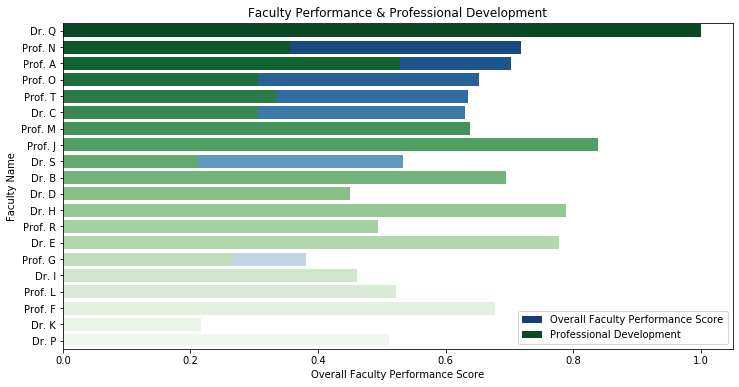

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort for better visualization based on Overall Faculty Performance Score (descending order)
df_sorted = df_scaled.sort_values(by='Overall Faculty Performance Score', ascending=False)

# Plot the last two columns: 'Overall Faculty Performance Score' and 'Professional Development'
plt.figure(figsize=(12, 6))

# Create a barplot for Overall Faculty Performance Score (darker colors for better performance)
sns.barplot(x='Overall Faculty Performance Score', y='Faculty Name', data=df_sorted, palette='Blues_r', label='Overall Faculty Performance Score')

# Create a barplot for Professional Development Score (darker colors for better performance)
sns.barplot(x='Professional Development', y='Faculty Name', data=df_sorted, palette='Greens_r', label='Professional Development')

# Adding labels and title
plt.xlabel('Overall Faculty Performance Score')
plt.ylabel('Faculty Name')
plt.title('Faculty Performance & Professional Development')

# Show the plot
plt.legend()
plt.show()


#### ✅ Machine Learning Models Included:
1️⃣ Ridge Regression

2️⃣ Lasso Regression

3️⃣ Decision Tree

4️⃣ Random Forest

5️⃣ XGBoost



In [ ]:
pip install xgboost


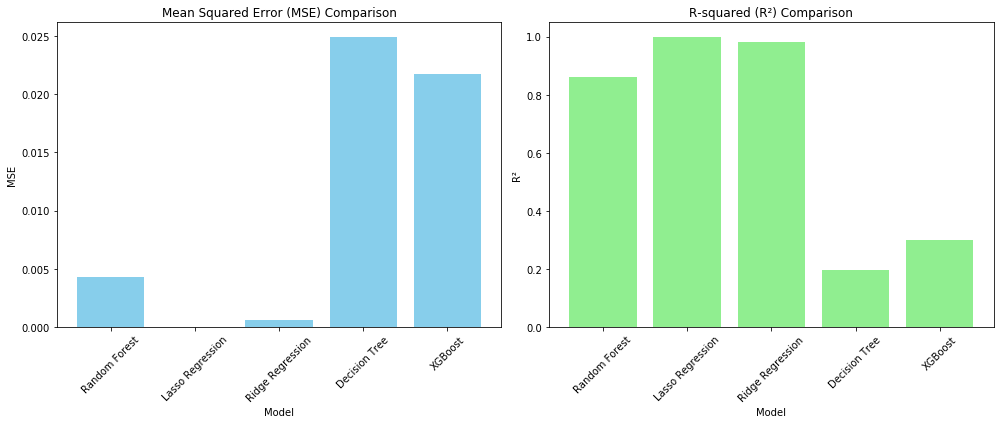

Mean Squared Error (MSE) scores: {'Random Forest': 0.0043370548637196, 'Lasso Regression': 2.712304965021398e-05, 'Ridge Regression': 0.000591449747782871, 'Decision Tree': 0.02490558951366812, 'XGBoost': 0.02175675747092367}
R-squared (R²) scores: {'Random Forest': 0.860238356256025, 'Lasso Regression': 0.9991259594075754, 'Ridge Regression': 0.9809405249554072, 'Decision Tree': 0.19741708642862865, 'XGBoost': 0.29888823585979607}


In [136]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Target variable
target = df_scaled['Overall Faculty Performance Score']

# Define columns to drop: 'Faculty ID', 'Faculty Name', 'Department', 'Qualification', and target 'Overall Faculty Performance Score'
columns_to_drop = ['Faculty ID', 'Faculty Name', 'Department', 'Qualification', 'Overall Faculty Performance Score']
features = df_scaled.drop(columns=columns_to_drop)

# Ensure that features are numeric (check the types of all columns)
features = features.select_dtypes(include=['float64', 'int64'])

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)



# 2. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# 3. Lasso Regression (with Cross-validation)
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

# 4. Ridge Regression
ridge = RidgeCV(cv=5)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

# 5. Decision Tree
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

# 6. XGBoost
xgboost = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgboost.fit(X_train, y_train)
xgboost_pred = xgboost.predict(X_test)

# Calculate performance metrics (Mean Squared Error and R-squared)
models = {
    "Random Forest": rf_pred,
    "Lasso Regression": lasso_pred,
    "Ridge Regression": ridge_pred,
    "Decision Tree": tree_pred,
    "XGBoost": xgboost_pred
}

mse_scores = {}
r2_scores = {}

for model_name, predictions in models.items():
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    mse_scores[model_name] = mse
    r2_scores[model_name] = r2

# Visualize the comparison of models based on MSE and R-squared
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot MSE scores
axes[0].bar(mse_scores.keys(), mse_scores.values(), color='skyblue')
axes[0].set_title('Mean Squared Error (MSE) Comparison')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability

# Plot R-squared scores
axes[1].bar(r2_scores.keys(), r2_scores.values(), color='lightgreen')
axes[1].set_title('R-squared (R²) Comparison')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability

plt.tight_layout()
plt.show()

# Print the scores for clarity
print("Mean Squared Error (MSE) scores:", mse_scores)
print("R-squared (R²) scores:", r2_scores)


#### MSE (Mean Squared Error) Scores:
#### Lower MSE values indicate better performance, as they represent less error between the predicted and actual values.

1. Random Forest: 0.0043
2.  Lasso Regression: 0.0000271 (very low error)
3.  Ridge Regression: 0.000591
4.   Decision Tree: 0.0249 (higher error)
5.   XGBoost: 0.0218 (higher error)

######  R² (R-squared) Scores:
######  Higher R² values indicate better performance, as they reflect how well the model explains the variance in the data.
1.  Random Forest: 0.8602 (good model fit, explains 86% of the variance)
2.  Lasso Regression: 0.9991 (very high fit, explains 99.91% of the variance)
3.  Ridge Regression: 0.9809 (good fit, explains 98.09% of the variance)
4.  Decision Tree: 0.1974 (very low fit, explains only 19.74% of the variance)
5.  XGBoost: 0.2989 (moderate fit, explains 29.89% of the variance)

#### Final Result:
1. Best Model: Lasso Regression is the best model overall, as it has the lowest MSE and the highest R², meaning it makes 
    the most accurate predictions and explains the variance in the data exceptionally well.

2. Second Best: Random Forest is a strong contender with good performance across both metrics, but Lasso edges it out with 
    slightly better results.

In [143]:
# Create a DataFrame for the test set with Faculty Name, Actual Score, and Lasso Predicted Score
df_test = df_scaled.iloc[X_test.index].copy()  # Only take rows corresponding to the test set

# Add Lasso predictions to the new DataFrame
df_test['Lasso Predicted'] = lasso_pred

# Print the results for Faculty Name, Actual Score, and Lasso Predicted Score
print(df_test[['Faculty Name', 'Overall Faculty Performance Score', 'Lasso Predicted']])


   Faculty Name  Overall Faculty Performance Score  Lasso Predicted
0       Prof. A                           0.702177         0.698871
17      Prof. R                           0.426204         0.429015
15        Dr. P                           0.213915         0.222540
1         Dr. B                           0.522721         0.526629


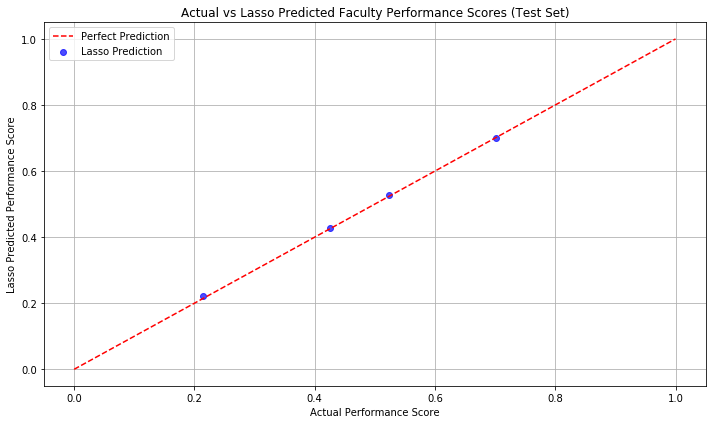

In [144]:
import matplotlib.pyplot as plt

# Plotting Actual vs Predicted Faculty Performance Scores for the test set
plt.figure(figsize=(10, 6))

# Scatter plot of Actual vs Predicted Scores
plt.scatter(df_test['Overall Faculty Performance Score'], df_test['Lasso Predicted'], color='blue', label='Lasso Prediction', alpha=0.7)

# Add a line for perfect prediction (y = x)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label="Perfect Prediction")

# Labeling
plt.title('Actual vs Lasso Predicted Faculty Performance Scores (Test Set)')
plt.xlabel('Actual Performance Score')
plt.ylabel('Lasso Predicted Performance Score')
plt.legend()

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()


In [145]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# Assuming df_scaled is the DataFrame containing your data

# Selecting only numeric columns
numeric_columns = [
    'Experience (Years)', 'QIP Participation Count', 'Previous Performance Score',
    'Student Feedback Score', 'Pass Percentage of Students', 'Innovative Teaching Methods Used',
    'Class Attendance Rate (%)', 'Research Papers Published (Last 2 Years)',
    'Research Funding Secured (in Rs)', 'Conference/Seminar Participation', 
    'Patents Filed/Granted', 'Overall Faculty Performance Score'
]

# Selecting the features (X) and target (y)
X = df_scaled[numeric_columns[:-1]]  # All columns except the target variable
y = df_scaled['Overall Faculty Performance Score']  # Target variable

# Log transform 'Research Funding Secured (in Rs)' (if it's highly skewed)
X['Research Funding Secured (in Rs)'] = np.log1p(X['Research Funding Secured (in Rs)'])

# Splitting data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Lasso model with cross-validation
lasso = LassoCV(cv=5, random_state=42)

# Fit the model on training data
lasso.fit(X_train_scaled, y_train)

# Predict on the test data
y_pred = lasso.predict(X_test_scaled)

# Calculate the performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the metrics
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")

# Example prediction with new numeric data
new_data_values = {
    'Experience (Years)': 5,
    'QIP Participation Count': 2,
    'Previous Performance Score': 75,
    'Student Feedback Score': 4.5,
    'Pass Percentage of Students': 50,
    'Innovative Teaching Methods Used': 3,
    'Class Attendance Rate (%)': 95,
    'Research Papers Published (Last 2 Years)': 4,
    'Research Funding Secured (in Rs)': 50000,  # Test with a lower value
    'Conference/Seminar Participation': 3,
    'Patents Filed/Granted': 1
}

# Create a DataFrame for the new data
new_data_df = pd.DataFrame([new_data_values])

# Log transform the 'Research Funding Secured (in Rs)' for the new data
new_data_df['Research Funding Secured (in Rs)'] = np.log1p(new_data_df['Research Funding Secured (in Rs)'])

# Scale the new data using the same scaler
new_data_scaled = scaler.transform(new_data_df)

# Predict the performance score for new data
new_prediction = lasso.predict(new_data_scaled)

# Clip the prediction to be within the 0-100 range (percentage)
new_prediction_percentage = max(0, min(new_prediction[0], 100))

# Print the predicted percentage
print(f"Predicted Overall Faculty Performance Score as a percentage: {new_prediction_percentage:.2f}%")


Mean Squared Error (MSE): 7.719649846113253e-06
R-squared (R²): 0.9997512341933588
Predicted Overall Faculty Performance Score as a percentage: 46.51%


C:\Users\User\Anaconda3\lib\site-packages\ipykernel_launcher.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
